#### Классификация новостей (Fake/True)

#### Имортируем библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf

#### Загрузка датасетов

In [2]:
fake_news = pd.read_csv('Fake.csv')
print(fake_news.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  


In [3]:
true_news = pd.read_csv('True.csv')
print(true_news.head())

                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   
3  December 30, 2017   
4  December 29, 2017   


In [4]:
fake_news['fake'] = 1

In [5]:
true_news['fake'] = 0

#### Создание общего датасета

In [6]:
news = pd.concat([fake_news, true_news])
news.sample(10, random_state=42)

,title,text,subject,date,fake
22216,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
4436,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
1526,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
1377,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
8995,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0
5766,Paul Ryan Responds To Dem’s Sit-In On Gun Con...,"On Wednesday, Democrats took a powerful stance...",News,"June 22, 2016",1
16230,AWESOME! DIAMOND AND SILK Rip Into The Press: ...,President Trump s rally in FL on Saturday was ...,Government News,"Feb 19, 2017",1
20911,STAND UP AND CHEER! UKIP Party Leader SLAMS Ge...,He s been Europe s version of the outspoken Te...,left-news,"Mar 8, 2016",1
12357,North Korea shows no sign it is serious about ...,WASHINGTON (Reuters) - The State Department sa...,worldnews,"December 13, 2017",0
9674,Trump signals willingness to raise U.S. minimu...,(This version of the story corrects the figur...,politicsNews,"May 4, 2016",0


In [7]:
news.isna().sum()

title      0
text       0
subject    0
date       0
fake       0
dtype: int64

In [8]:
news.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   fake     44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


#### Исследовательский анализ данных

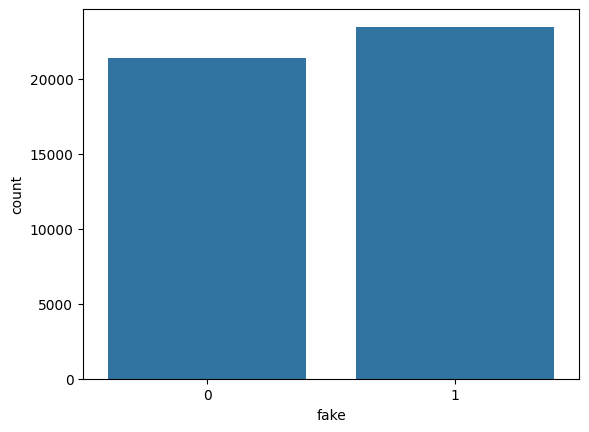

In [9]:
sns.countplot(x='fake', data=news)
plt.show()

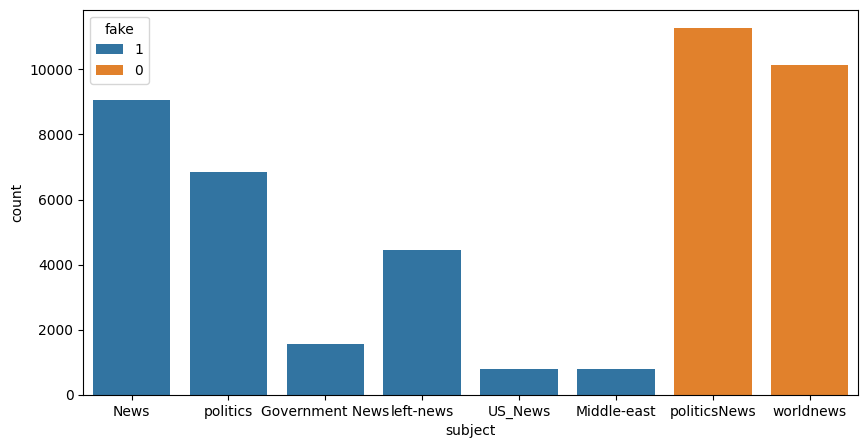

In [10]:
plt.figure(figsize=(10,5))
news['fake'] = news['fake'].astype(str)
sns.countplot(x='subject', data=news, hue='fake')
plt.show()

In [11]:
news['text'] = news['title'] + news['text']
news = news.drop(labels=('title'), axis=1)
news.head()

,text,subject,date,fake
0,Donald Trump Sends Out Embarrassing New Year’...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,News,"December 25, 2017",1


In [12]:
news = news.drop(labels=['subject', 'date'], axis=1)
news.head()

,text,fake
0,Donald Trump Sends Out Embarrassing New Year’...,1
1,Drunk Bragging Trump Staffer Started Russian ...,1
2,Sheriff David Clarke Becomes An Internet Joke...,1
3,Trump Is So Obsessed He Even Has Obama’s Name...,1
4,Pope Francis Just Called Out Donald Trump Dur...,1


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, Y_test = train_test_split(news['text'].to_numpy(), news['fake'].to_numpy(), test_size=0.2, random_state=42)


In [14]:
round(sum([len(i.split()) for i in X_train]) / len(X_train))

417

In [16]:
max_vocab_length = 10000
max_length = 417

In [17]:
from keras.layers import TextVectorization
text_vectorizer = TextVectorization(max_tokens=max_vocab_length, output_mode='int', output_sequence_length=max_length)
text_vectorizer.adapt(X_train)

2026-04-10 18:16:30.972022: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-04-10 18:16:30.972585: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-10 18:16:30.973244: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-10 18:16:30.973316: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-10 18:16:30.974004: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [18]:
sample_sentense = 'Hello, World! Hello, World! Hello, World! Hello, World! Hello, World! I dont speak English'
text_vectorizer([sample_sentense])

<tf.Tensor: shape=(1, 417), dtype=int64, numpy=
array([[   1,  180,    1,  180,    1,  180,    1,  180,    1,  180,   37,
        4893,  952, 2708,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,   

In [19]:
import random
random_sentense = random.choice(X_train)
print(random_sentense, text_vectorizer(random_sentense))

U.S. special envoy says Kurdish referendum has 'a lot of risks'NEW YORK (Reuters) - The U.S. presidential envoy to the coalition fighting the Islamic State insurgent group said on Friday that a referendum on Kurdish independence in northern Iraq  carries a lot of risks.  The envoy, Brett McGurk, told reporters:  The (Kurdish) referendum just carries an awful lot of risks and that s not something the United States can control. ... In terms of the consequences of the referendum it s not something that we can fully control, (it) just carries a lot of risks.   tf.Tensor(
[  31  489 3937  143 1056 1286   22    6  498    4    1  224   71    2
   31  138 3937    3    2  550  784    2  322   60 6254  163   14    9
  213    8    6 1286    9 1056  942    7  989  472 5522    6  498    4
 2854    2 3937    1    1   86  359    2 1056 1286   77 5522   32 4643
  498    4 2854    5    8   11   25  312    2   87   76   75  349    7
 1130    4    2 2157    4    2 1286   16   11   25  312    8   36   75


In [ ]:
from keras import layers
